In [4]:
# ── 0. Install & Imports ──────────────────────────────────────────────────────
import subprocess, sys

# Works in VS Code, JupyterLab, classic Notebook — everywhere
for pkg in ['plotly', 'kaleido']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from matplotlib.patches import Patch

# ── Global matplotlib style ──
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
})

PALETTE = sns.color_palette('tab10')
BLUE    = '#2563EB'
ORANGE  = '#F59E0B'
GREEN   = '#10B981'
RED     = '#EF4444'

print('✅ All libraries ready.')



✅ All libraries ready.


In [11]:
# ── 1. Load Data ──────────────────────────────────────────────────────────────
CSV_PATH = Path(r'C:\Users\Faiyaz\Downloads\gdp_data (1).csv') # change path if needed

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'Cannot find {CSV_PATH.resolve()}\n'
        'Put gdp_data.csv in the same folder as this notebook and re-run.'
    )

df = pd.read_csv(CSV_PATH)
df['Value_T'] = df['Value'] / 1e12   # convert to USD trillions

print(f'Shape      : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns    : {list(df.columns)}')
print(f'Countries  : {df["Country Name"].nunique()}')
print(f'Year range : {df["Year"].min()} - {df["Year"].max()}')
df.head(10)

FileNotFoundError: Cannot find C:\Users\Faiyaz\Downloads\gdp_data (1).csv
Put gdp_data.csv in the same folder as this notebook and re-run.

In [9]:
import os
print(os.getcwd())

C:\Users\Faiyaz


In [10]:
import os
print(os.listdir(r'C:\Users\Faiyaz\Downloads'))

['.ipynb_checkpoints', '02. IA 2 - Business Email + Interview (CASD - English) - MCA 1B (1).pdf', '02. IA 2 - Business Email + Interview (CASD - English) - MCA 1B.pdf', '10 m.pdf', '123.pdf', '5108.pdf', 'aa (1).pdf', 'aa.pdf', 'ADBMS Assignment 3.docx', 'ADBMS Assignment 4.docx', 'ADBMS Assignment 5.docx', 'ADBMS Assignment 6.docx', 'ADBMS_Assignment 2 (1).docx', 'ADBMS_Assignment 2 (2).docx', 'ADBMS_Assignment 2.docx', 'ADBMS_Group_A_2_Marks_Questions.pdf', 'adil.pdf', 'Adobe Scan 06 Feb 2026 (1).pdf', 'Adobe Scan 06 Feb 2026.pdf', 'ADV JAVA.docx', 'Adv.Java final.pdf', 'ai_ml_lab_assignment_index.pdf', 'ai_ml_lab_index_full_page.pdf', 'Anaconda3-2025.12-1-Windows-x86_64.exe', 'Anaconda3-2025.12-2-Windows-x86_64.exe', 'Ashutosh Kumar Ojha_251001271120_DAA_MCA1B.pdf', 'Ashutosh_Kumar_Ojha_251001271120_MCA1B_CASDENG_IA2.pdf', 'Ask.Me.What.You.Want.2024.1080p.BluRay.HIN-ENG.x264-Vegamovies.is.mkv', 'Big_Data_Analytics_Assignment.pdf', 'BIODATA RUHI KHAN.pdf', 'BLOCKCHAIN_FINAL.docx', 'B

In [25]:
from pathlib import Path
import pandas as pd

# --- 1. Load Data ---
CSV_PATH = Path(r"C:\Users\Faiyaz\OneDrive\Desktop\gdp_data.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'Cannot find {CSV_PATH.resolve()}\n'
        'Put gdp_data.csv in the same folder as this notebook and re-run.'
    )

df = pd.read_csv(CSV_PATH)
df['Value_T'] = df['Value'] / 1e12

print(f'Shape      : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns    : {list(df.columns)}')
print(f'Countries  : {df["Country Name"].nunique()}')
print(f'Year range : {df["Year"].min()} - {df["Year"].max()}')

df.head(10)

Shape      : 960 rows x 5 columns
Columns    : ['Country Name', 'Country Code', 'Year', 'Value', 'Value_T']
Countries  : 40
Year range : 2000 - 2023


,Country Name,Country Code,Year,Value,Value_T
0,United States,USA,2000,1.025000e+13,10.250000
1,United States,USA,2001,1.073019e+13,10.730194
2,United States,USA,2002,1.111199e+13,11.111991
3,United States,USA,2003,1.151412e+13,11.514123
4,United States,USA,2004,1.207823e+13,12.078230
5,United States,USA,2005,1.270538e+13,12.705380
6,United States,USA,2006,1.278873e+13,12.788733
7,United States,USA,2007,1.307132e+13,13.071319
8,United States,USA,2008,1.364018e+13,13.640181
9,United States,USA,2009,1.376601e+13,13.766006


In [27]:
print('=' * 55)
print('DTYPES')
print('=' * 55)
print(df.dtypes)
 
print('\n' + '=' * 55)
print('MISSING VALUES')
print('=' * 55)
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing cells : {missing.sum()}')
 
print('\n' + '=' * 55)
print('DESCRIPTIVE STATISTICS')
print('=' * 55)
df[['Year', 'Value_T']].describe().round(3)

DTYPES
Country Name     object
Country Code     object
Year              int64
Value           float64
Value_T         float64
dtype: object

MISSING VALUES
Country Name    0
Country Code    0
Year            0
Value           0
Value_T         0
dtype: int64

Total missing cells : 0

DESCRIPTIVE STATISTICS


,Year,Value_T
count,960.000,960.000
mean,2011.500,1.138
std,6.926,2.687
min,2000.000,0.012
25%,2005.750,0.167
50%,2011.500,0.330
75%,2017.250,0.912
max,2023.000,22.127


In [29]:
pivot_check = df.pivot(index='Year', columns='Country Name', values='Value')
 
print(f'Expected rows : {pivot_check.shape[0] * pivot_check.shape[1]}')
print(f'Actual rows   : {len(df)}')
print(f'Missing cells : {pivot_check.isnull().sum().sum()}')
print()
print('Countries in dataset:')
for i, c in enumerate(sorted(df['Country Name'].unique()), 1):
    print(f'  {i:>2}. {c}')

Expected rows : 960
Actual rows   : 960
Missing cells : 0

Countries in dataset:
   1. Argentina
   2. Australia
   3. Bangladesh
   4. Belgium
   5. Brazil
   6. Canada
   7. Chile
   8. China
   9. Colombia
  10. Egypt
  11. France
  12. Germany
  13. India
  14. Indonesia
  15. Ireland
  16. Israel
  17. Italy
  18. Japan
  19. Kenya
  20. Malaysia
  21. Mexico
  22. Netherlands
  23. Nigeria
  24. Norway
  25. Pakistan
  26. Philippines
  27. Poland
  28. Russia
  29. Saudi Arabia
  30. Singapore
  31. South Africa
  32. South Korea
  33. Spain
  34. Sweden
  35. Switzerland
  36. Thailand
  37. Turkey
  38. United Kingdom
  39. United States
  40. Vietnam


C:\Users\Faiyaz\AppData\Local\Temp\ipykernel_23512\49895817.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_by_year, labels=years_sample, patch_artist=True,


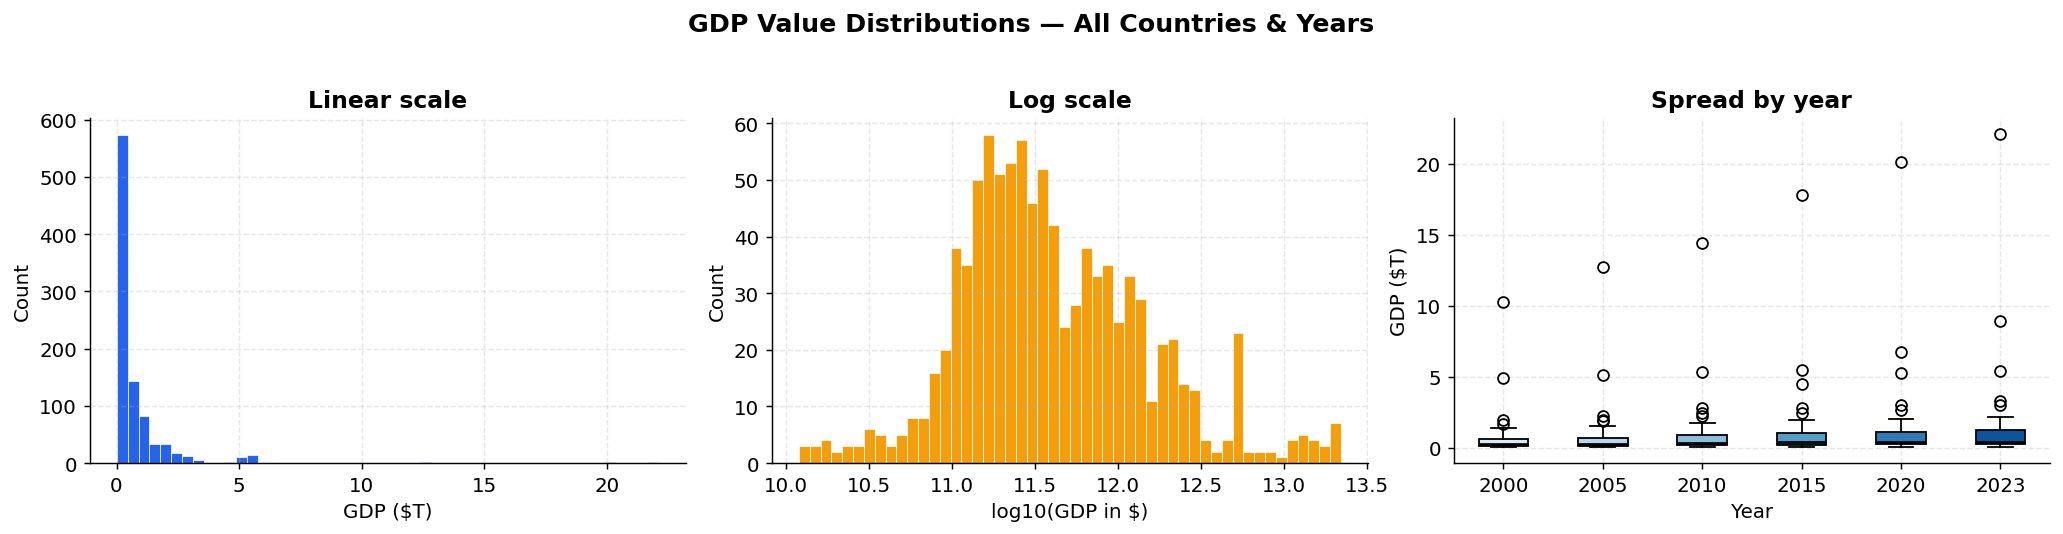

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# Linear histogram
axes[0].hist(df['Value_T'], bins=50, color=BLUE, edgecolor='white', linewidth=0.4)
axes[0].set(xlabel='GDP ($T)', ylabel='Count', title='Linear scale')
 
# Log histogram
axes[1].hist(np.log10(df['Value'] + 1), bins=50, color=ORANGE,
             edgecolor='white', linewidth=0.4)
axes[1].set(xlabel='log10(GDP in $)', ylabel='Count', title='Log scale')
 
# Box plot per year
years_sample = [2000, 2005, 2010, 2015, 2020, 2023]
data_by_year = [df[df['Year'] == y]['Value_T'].values for y in years_sample]
bp = axes[2].boxplot(data_by_year, labels=years_sample, patch_artist=True,
                     medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], sns.color_palette('Blues', len(years_sample))):
    patch.set_facecolor(color)
axes[2].set(xlabel='Year', ylabel='GDP ($T)', title='Spread by year')
 
fig.suptitle('GDP Value Distributions — All Countries & Years',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

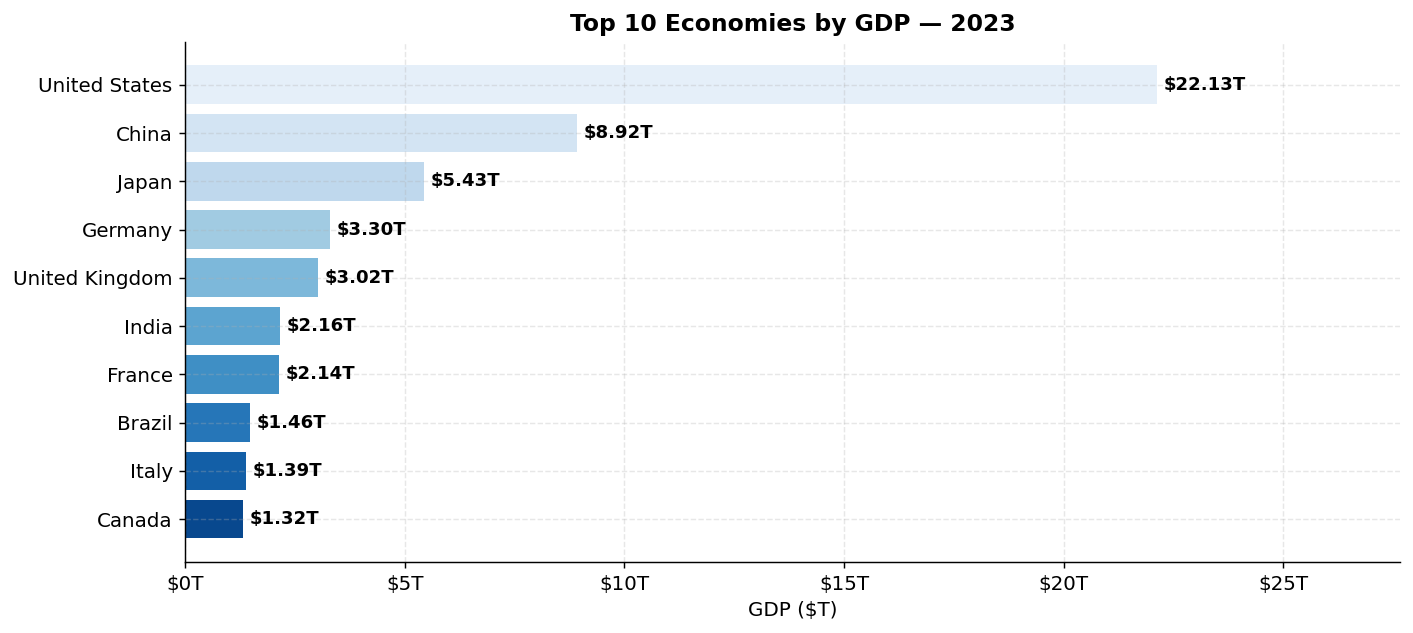

  Country Name  GDP ($T)
 United States 22.126520
         China  8.916963
         Japan  5.432424
       Germany  3.304678
United Kingdom  3.017953
         India  2.160640
        France  2.143903
        Brazil  1.464993
         Italy  1.389315
        Canada  1.320381


In [32]:
top10 = (
    df[df['Year'] == 2023]
    .sort_values('Value_T', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
 
fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Blues_r', 10)
bars = ax.barh(top10['Country Name'][::-1], top10['Value_T'][::-1], color=colors)
 
for bar, val in zip(bars, top10['Value_T'][::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f'${val:.2f}T', va='center', fontsize=10, fontweight='bold')
 
ax.set(xlabel='GDP ($T)', title='Top 10 Economies by GDP — 2023')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fT'))
ax.set_xlim(0, top10['Value_T'].max() * 1.25)
plt.tight_layout()
plt.show()
 
print(top10[['Country Name', 'Value_T']].rename(columns={'Value_T': 'GDP ($T)'}).to_string(index=False))

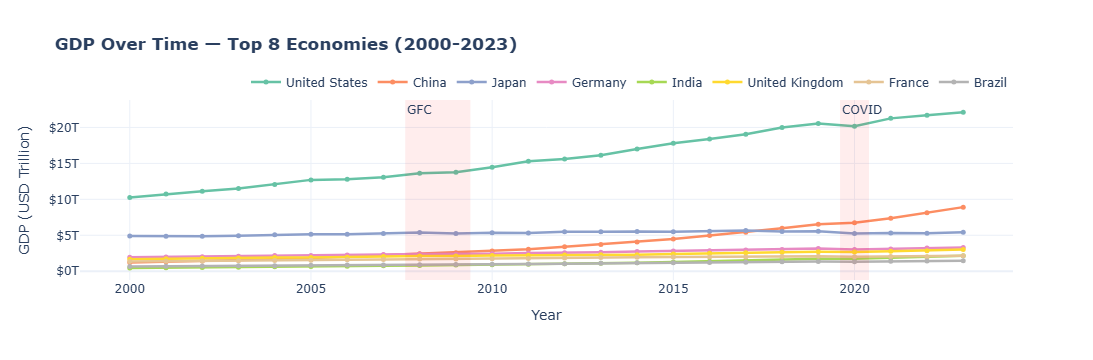

In [33]:
# ── 6. GDP Over Time — Top 8 (Interactive Plotly) ────────────────────────────
top8_names = (
    df[df['Year'] == 2023]
    .sort_values('Value_T', ascending=False)
    .head(8)['Country Name']
    .tolist()
)
 
df_top8 = df[df['Country Name'].isin(top8_names)]
 
fig = px.line(
    df_top8, x='Year', y='Value_T',
    color='Country Name',
    markers=True,
    title='<b>GDP Over Time — Top 8 Economies (2000-2023)</b>',
    labels={'Value_T': 'GDP (USD Trillion)', 'Country Name': ''},
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=5), line=dict(width=2.5))
fig.update_layout(
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    yaxis_tickprefix='$',
    yaxis_ticksuffix='T',
)
 
# Shade recession bands
for x0, x1, label in [(2008, 2009, 'GFC'), (2020, 2020, 'COVID')]:
    fig.add_vrect(x0=x0 - 0.4, x1=x1 + 0.4, fillcolor='red', opacity=0.07,
                  line_width=0, annotation_text=label,
                  annotation_position='top left')
fig.show()

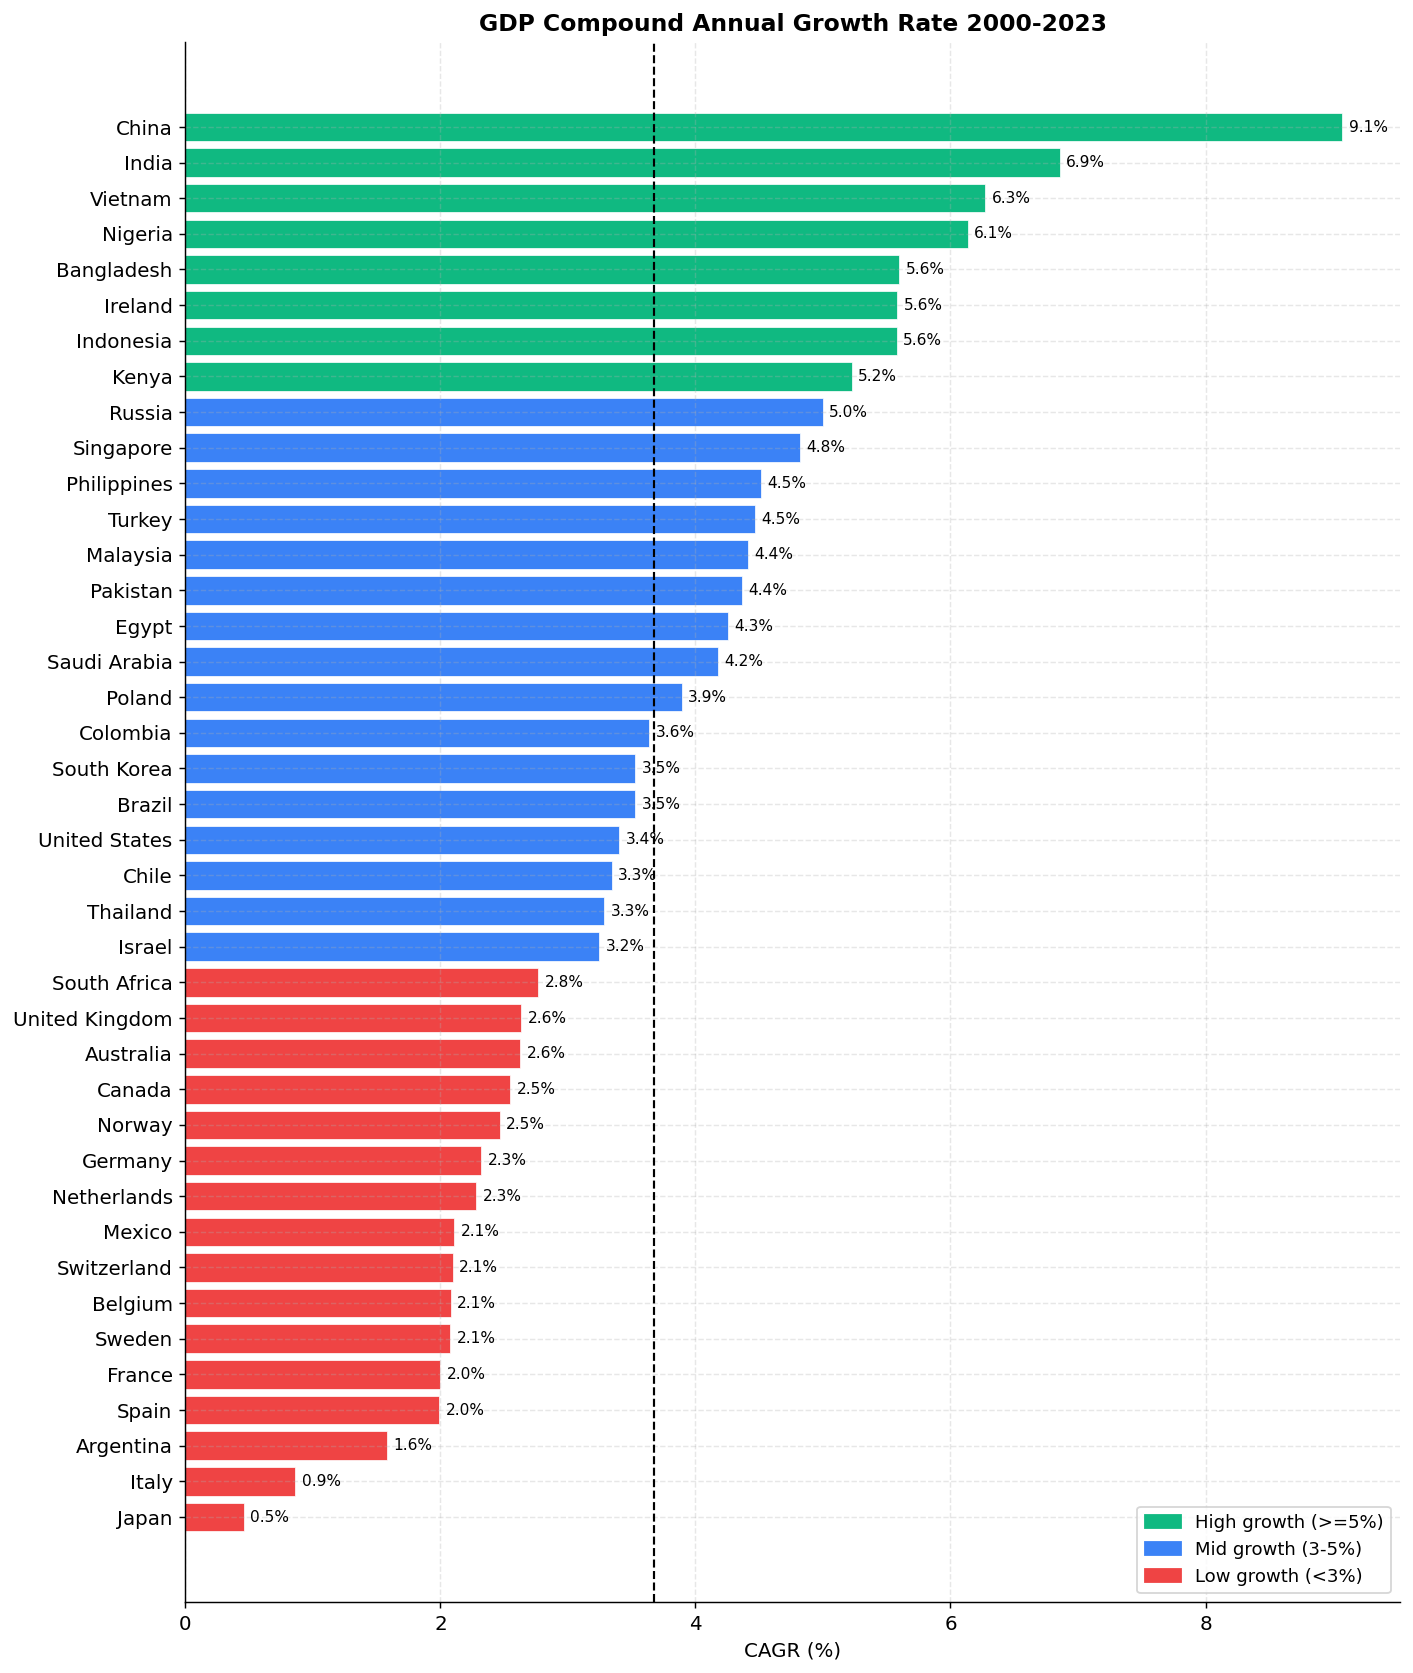


Full CAGR table:
       Country     CAGR
         China 9.072287
         India 6.857171
       Vietnam 6.273054
       Nigeria 6.136823
    Bangladesh 5.599720
       Ireland 5.581339
     Indonesia 5.578197
         Kenya 5.227139
        Russia 4.998030
     Singapore 4.820562
   Philippines 4.513754
        Turkey 4.466175
      Malaysia 4.414636
      Pakistan 4.363095
         Egypt 4.256510
  Saudi Arabia 4.176140
        Poland 3.893071
      Colombia 3.639035
   South Korea 3.528537
        Brazil 3.527601
 United States 3.402245
         Chile 3.342823
      Thailand 3.285966
        Israel 3.247360
  South Africa 2.769155
United Kingdom 2.633030
     Australia 2.627484
        Canada 2.549459
        Norway 2.466995
       Germany 2.320024
   Netherlands 2.279931
        Mexico 2.110805
   Switzerland 2.097519
       Belgium 2.082294
        Sweden 2.078335
        France 1.998594
         Spain 1.989979
     Argentina 1.583046
         Italy 0.863633
         Japan 0.45840

In [35]:
# ── 7. CAGR 2000-2023 — All Countries ────────────────────────────────────────
gdp_start = df[df['Year'] == 2000].set_index('Country Name')['Value']
gdp_end   = df[df['Year'] == 2023].set_index('Country Name')['Value']
cagr_s    = ((gdp_end / gdp_start) ** (1 / 23) - 1) * 100
cagr_df   = cagr_s.sort_values(ascending=False).reset_index()
cagr_df.columns = ['Country', 'CAGR']

bar_colors = ['#10B981' if v >= 5 else '#3B82F6' if v >= 3 else '#EF4444'
              for v in cagr_df['CAGR']]

fig, ax = plt.subplots(figsize=(11, 13))
ax.barh(cagr_df['Country'][::-1], cagr_df['CAGR'][::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.4)
ax.axvline(cagr_df['CAGR'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Mean {cagr_df['CAGR'].mean():.1f}%")

# Value labels
for i, (_, row) in enumerate(cagr_df[::-1].iterrows()):
    ax.text(row['CAGR'] + 0.05, i, f"{row['CAGR']:.1f}%",
            va='center', fontsize=8.5)

ax.legend(handles=[
    Patch(color='#10B981', label='High growth (>=5%)'),
    Patch(color='#3B82F6', label='Mid growth (3-5%)'),
    Patch(color='#EF4444', label='Low growth (<3%)'),
], loc='lower right', fontsize=10)
ax.set(xlabel='CAGR (%)', title='GDP Compound Annual Growth Rate 2000-2023')
plt.tight_layout()
plt.show()

print('\nFull CAGR table:')
print(cagr_df.to_string(index=False))

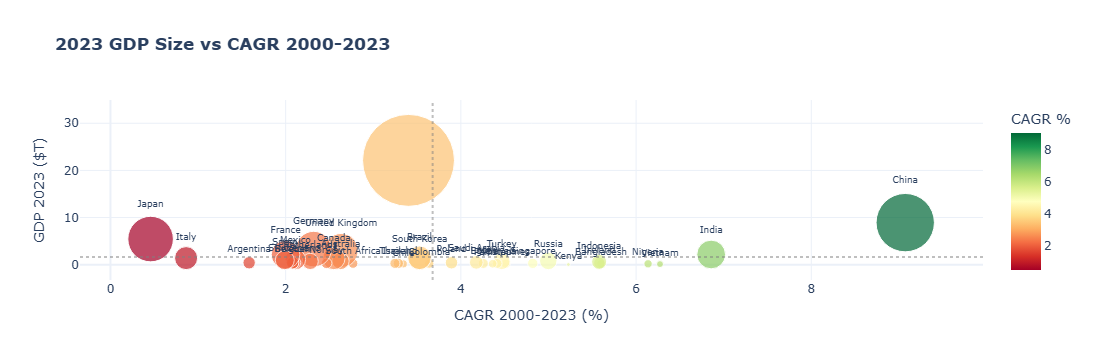

In [36]:
# ── 8. Size vs Growth Bubble Chart (Interactive) ─────────────────────────────
gdp2023   = df[df['Year'] == 2023].set_index('Country Name')['Value_T']
bubble_df = cagr_df.copy()
bubble_df['GDP_2023'] = bubble_df['Country'].map(gdp2023)

fig = px.scatter(
    bubble_df,
    x='CAGR', y='GDP_2023',
    size='GDP_2023', size_max=65,
    text='Country',
    color='CAGR',
    color_continuous_scale='RdYlGn',
    hover_data={'CAGR': ':.2f', 'GDP_2023': ':.3f'},
    title='<b>2023 GDP Size vs CAGR 2000-2023</b>',
    labels={'CAGR': 'CAGR 2000-2023 (%)', 'GDP_2023': 'GDP 2023 ($T)'},
    template='plotly_white'
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(
    coloraxis_colorbar=dict(title='CAGR %'),
)

# Quadrant lines at means
fig.add_hline(y=bubble_df['GDP_2023'].mean(), line_dash='dot',
              line_color='gray', opacity=0.5)
fig.add_vline(x=bubble_df['CAGR'].mean(), line_dash='dot',
              line_color='gray', opacity=0.5)
fig.show()